# EDA: Online Retail (UK) dataset

End-to-end exploratory analysis: data cleaning, revenue trends, customer concentration, cohort retention, and a UK-specific view.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)

In [2]:
# Load data (Latin-1 for this CSV)
ecom = pd.read_csv(Path("./data/ecom_data.csv"), encoding="latin-1")
ecom["InvoiceDate"] = pd.to_datetime(ecom["InvoiceDate"])
print(ecom.shape)
ecom.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
ecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
ecom.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,NaN,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


## 1. Returns and negative quantities

Negative Quantity values are returns or adjustments; InvoiceNo starting with “C” are credit notes. Quick check of how much these overlap, then both are dropped for the sales analysis.

In [5]:
ecom["InvoiceNo_starts_C"] = ecom["InvoiceNo"].astype(str).str.startswith("C")
ecom["Quantity_negative"] = ecom["Quantity"] < 0
print(pd.crosstab(ecom["Quantity_negative"], ecom["InvoiceNo_starts_C"], margins=True, margins_name="Total"))

returns = ecom[ecom["Quantity"] < 0]
purchases = ecom[ecom["Quantity"] > 0]
print(f"Total returns (negative quantity): {len(returns)}")
print(f"Total purchases (positive quantity): {len(purchases)}")
print(f"Unique return invoices (InvoiceNo): {returns['InvoiceNo'].nunique()}")
print(f"Unique purchase invoices (InvoiceNo): {purchases['InvoiceNo'].nunique()}")

InvoiceNo_starts_C   False  True   Total
Quantity_negative                       
False               531285     0  531285
True                  1336  9288   10624
Total               532621  9288  541909
Total returns (negative quantity): 10624
Total purchases (positive quantity): 531285
Unique return invoices (InvoiceNo): 5172
Unique purchase invoices (InvoiceNo): 20728


## 2. Missing CustomerID

A significant portion of rows have no CustomerID — likely guest checkouts or channel orders. Worth understanding how they’re distributed before deciding whether to include them. Also checking whether any single invoice mixes rows with and without an ID.

In [6]:
no_cust = ecom[ecom["CustomerID"].isna()]
pd.crosstab(no_cust["Quantity_negative"], no_cust["InvoiceNo_starts_C"], margins=True, margins_name="Total")

InvoiceNo_starts_C,False,True,Total
Quantity_negative,,,
False,133361,0,133361
True,1336,383,1719
Total,134697,383,135080


In [7]:
by_inv = ecom.groupby("InvoiceNo")["CustomerID"].agg(has_id=lambda x: x.notna().any(), has_nan=lambda x: x.isna().any())
mixed = by_inv[by_inv["has_id"] & by_inv["has_nan"]]
print(f"Invoices with both ID and no-ID rows: {len(mixed)}")

Invoices with both ID and no-ID rows: 0


## 3. Cleaning for sales analysis

Keep rows with Quantity > 0 and InvoiceNo not starting with C. Add a Revenue column; drop rows with very low revenue that look like data noise.

Also remove non-product StockCodes — administrative entries that appear in the data but are not sellable products:

| StockCode | Description |
|-----------|-------------|
| DOT | DOTCOM POSTAGE |
| POST | POSTAGE |
| M | Manual adjustment |
| B | Adjust bad debt |
| AMAZONFEE | Amazon fee |

These are identified by the pattern that all real product codes start with a digit (e.g. `85123A`, `22423`), while administrative codes are purely alphabetic. The filter `StockCode.str.match(r'^\d')` removes all of them in one step.

In [8]:
ecom2 = ecom[(ecom["Quantity"] > 0) & (~ecom["InvoiceNo_starts_C"])].copy()
ecom2["Revenue"] = ecom2["Quantity"] * ecom2["UnitPrice"]
ecom2 = ecom2[ecom2["Revenue"] >= 0.1]

before = len(ecom2)
ecom2 = ecom2[ecom2["StockCode"].str.match(r'^\d')]
removed = before - len(ecom2)
print(f"Non-product rows removed (administrative StockCodes): {removed}")

print(ecom2.shape)
total_revenue = round(ecom2["Revenue"].sum(), 2)
print(f"Total revenue (products only): {total_revenue}")

Non-product rows removed (administrative StockCodes): 2374
(527723, 11)
Total revenue (products only): 10271034.49


## 4. Revenue over time

Monthly revenue and top 3 countries by revenue per month.

,Revenue
InvoiceDate,
2010-12,777865.64
2011-01,671914.94
2011-02,508869.75
2011-03,691132.59
2011-04,516194.91
2011-05,741153.76
2011-06,738751.87
2011-07,689289.86
2011-08,725493.76


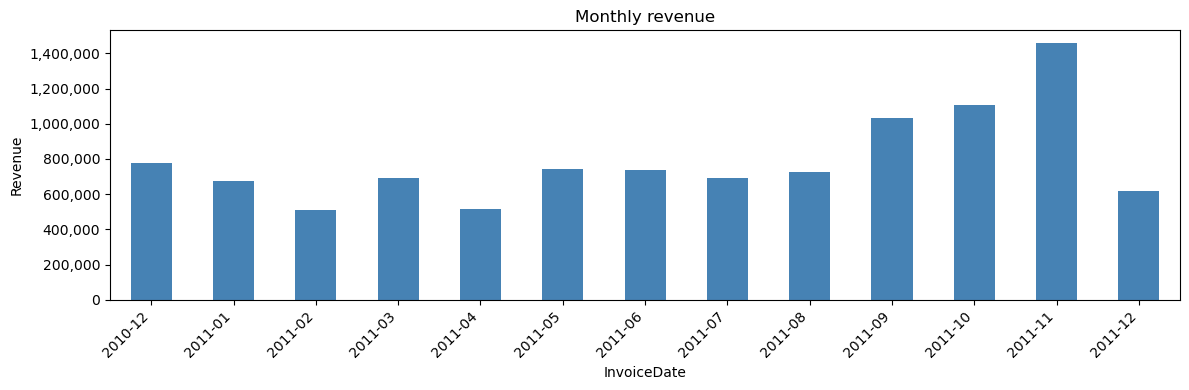

In [9]:
ecom2_indexed = ecom2.set_index("InvoiceDate")
monthly_revenue = ecom2_indexed.resample("ME")["Revenue"].sum()
monthly_revenue.index = monthly_revenue.index.strftime("%Y-%m")

display(monthly_revenue.to_frame("Revenue"))

fig, ax = plt.subplots(figsize=(12, 4))
monthly_revenue.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xticklabels(monthly_revenue.index, rotation=45, ha="right")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"{x:,.0f}"))
ax.set_title("Monthly revenue")
plt.tight_layout()
plt.show()

,Total_Revenue
Country,
United Kingdom,8747163.09
Netherlands,283889.34
EIRE,271164.30
Germany,205569.89
France,184582.74
Australia,138171.31
Spain,55725.11
Switzerland,53087.90
Japan,37416.37


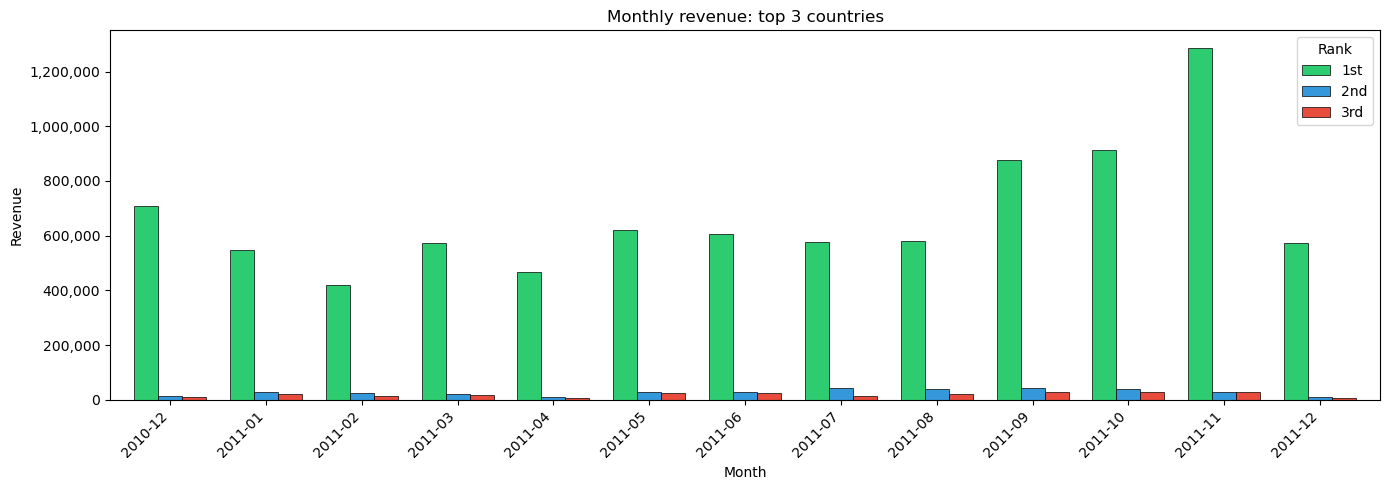

In [10]:
ecom2["Month"] = ecom2["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
rev_mc = ecom2.groupby(["Month", "Country"])["Revenue"].sum().reset_index()
top3 = rev_mc.sort_values(["Month", "Revenue"], ascending=[True, False]).groupby("Month").head(3)
top3["Rank"] = top3.groupby("Month").cumcount() + 1
pivot_rev = top3.pivot(index="Month", columns="Rank", values="Revenue")
pivot_rev.columns = ["1st", "2nd", "3rd"]
pivot_rev.index = pivot_rev.index.strftime("%Y-%m")

top10_total = ecom2.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10).to_frame("Total_Revenue")
display(top10_total)

fig, ax = plt.subplots(figsize=(14, 5))
pivot_rev.plot(kind="bar", ax=ax, width=0.75, color=["#2ecc71", "#3498db", "#e74c3c"], edgecolor="black", linewidth=0.5)
ax.set_xticklabels(pivot_rev.index, rotation=45, ha="right")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
ax.set_title("Monthly revenue: top 3 countries")
ax.legend(title="Rank")

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

December is the peak month (holiday season), with revenue clearly above the rest of the year. There are dips in February and April, then relative stability through the rest of the period. The pattern looks like Q4 seasonality plus modest overall growth — though with only ~13 months of data, it’s hard to be confident about the growth trend.

## 5. Customer-level metrics (RFM-style)

Total revenue, order count, first and last order date, days since last purchase, and average order value per customer. Then a look at who the top 20% by revenue actually are.

In [11]:
ref_date = ecom2["InvoiceDate"].max()
rmf_customers = ecom2.groupby("CustomerID").agg(
    total_revenue=("Revenue", "sum"),
    total_orders=("InvoiceNo", "nunique"),
    first_order_date=("InvoiceDate", "min"),
    last_order_date=("InvoiceDate", "max"),
)
rmf_customers["days_since_last_purchase"] = (ref_date - rmf_customers["last_order_date"]).dt.days
rmf_customers["avg_order_value"] = (rmf_customers["total_revenue"] / rmf_customers["total_orders"]).round(2)
rmf_customers = rmf_customers.sort_values("total_revenue", ascending=False)
print(rmf_customers.shape)
rmf_customers.head(10)

(4334, 6)


,total_revenue,total_orders,first_order_date,last_order_date,days_since_last_purchase,avg_order_value
CustomerID,,,,,,
14646.0,279138.02,72,2010-12-20 10:09:00,2011-12-08 12:12:00,1,3876.92
18102.0,259657.30,60,2010-12-07 16:42:00,2011-12-09 11:50:00,0,4327.62
17450.0,194550.79,46,2010-12-07 09:23:00,2011-12-01 13:29:00,7,4229.36
16446.0,168472.50,2,2011-05-18 09:52:00,2011-12-09 09:15:00,0,84236.25
14911.0,136275.72,198,2010-12-01 14:05:00,2011-12-08 15:54:00,0,688.26
12415.0,124564.53,20,2011-01-06 11:12:00,2011-11-15 14:22:00,23,6228.23
14156.0,116729.63,54,2010-12-03 11:48:00,2011-11-30 10:54:00,9,2161.66
17511.0,91062.38,31,2010-12-01 10:19:00,2011-12-07 10:12:00,2,2937.50
12346.0,77183.60,1,2011-01-18 10:01:00,2011-01-18 10:01:00,325,77183.60


In [12]:
threshold = rmf_customers["total_revenue"].quantile(0.80)
top20 = rmf_customers[rmf_customers["total_revenue"] >= threshold]
print(f"Top 20% by revenue: {len(top20)} customers")

Top 20% by revenue: 867 customers


In [13]:
total_revenue = rmf_customers["total_revenue"].sum()
total_revenue_top20 = top20["total_revenue"].sum()
print(f"Total revenue of top 20% customers: {total_revenue_top20}")
print(f"Percentage of total: {100*total_revenue_top20/total_revenue:.2f}%")
print(f"Total revenue of bottom 80% customers: {round(total_revenue - total_revenue_top20,2)}")
print(f"Percentage of total: {100*(total_revenue - total_revenue_top20)/total_revenue:.2f}%")
print(f"Total revenue: {round(total_revenue,2)}")

Total revenue of top 20% customers: 6530191.09
Percentage of total: 74.54%
Total revenue of bottom 80% customers: 2230875.5
Percentage of total: 25.46%
Total revenue: 8761066.59


## 6. Revenue distribution

Customer revenue is heavily right-skewed — log scale makes the shape easier to read.

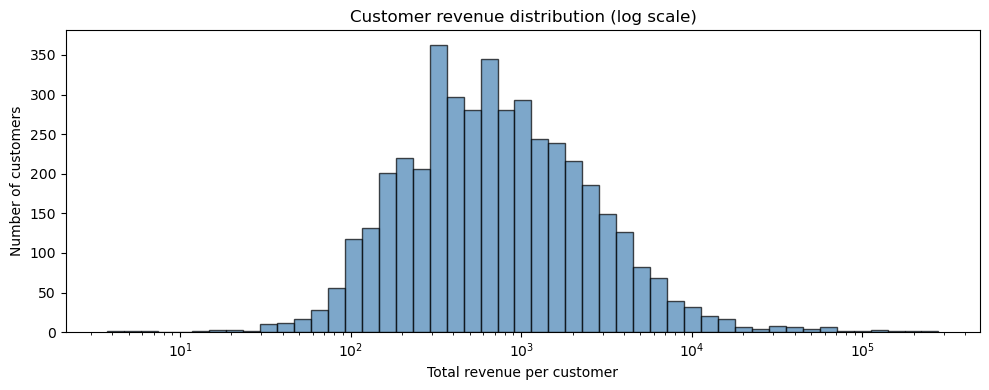

In [14]:
rev = rmf_customers["total_revenue"][rmf_customers["total_revenue"] > 0]
bins = np.logspace(np.log10(rev.min()), np.log10(rev.max()), 50)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(rev, bins=bins, edgecolor="black", alpha=0.7, color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Total revenue per customer")
ax.set_ylabel("Number of customers")
ax.set_title("Customer revenue distribution (log scale)")
plt.tight_layout()
plt.show()

## 7. Who are the top 20%?

Country mix, recency, frequency, and whether these customers tend to be repeat buyers or high-ticket (fewer, larger orders).

Top 20% by country:
Country
United Kingdom     747
Germany             30
France              26
Belgium              8
Spain                7
Switzerland          7
Norway               5
Portugal             4
Japan                4
Cyprus               3
Denmark              3
EIRE                 3
Australia            3
Italy                3
Finland              2
Israel               2
Channel Islands      2
Sweden               1
Netherlands          1
Singapore            1
Iceland              1
Poland               1
Greece               1
Canada               1
Austria              1
Name: count, dtype: int64


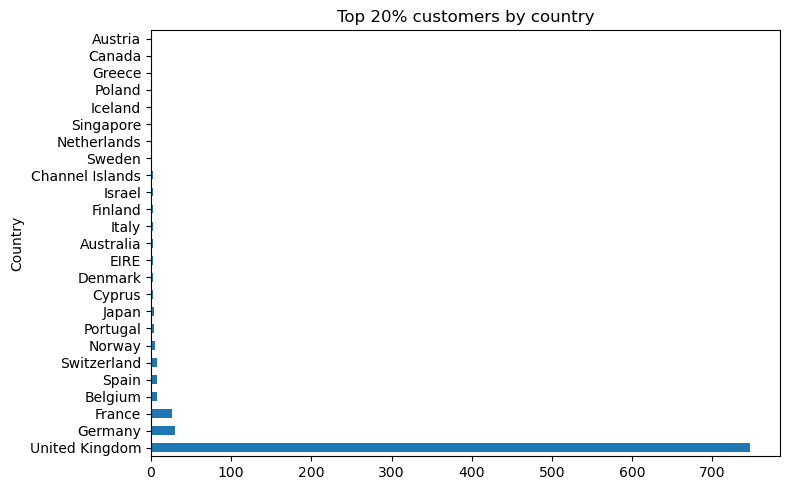

In [15]:
top20 = rmf_customers[rmf_customers["total_revenue"] >= threshold].copy()
country_map = ecom2[["CustomerID", "Country"]].drop_duplicates("CustomerID")
top20_c = top20.merge(country_map, on="CustomerID")
print("Top 20% by country:")
print(top20_c["Country"].value_counts())
top20_c["Country"].value_counts().plot(kind="barh", figsize=(8, 5))
plt.title("Top 20% customers by country")
plt.tight_layout()
plt.show()

Recency: count    867.000000
mean      31.580161
std       47.678087
min        0.000000
25%        4.000000
50%       15.000000
75%       37.000000
max      371.000000
Name: days_since_last_purchase, dtype: float64

Frequency: count    867.000000
mean      11.662053
std       14.430449
min        1.000000
25%        5.000000
50%        8.000000
75%       13.000000
max      206.000000
Name: total_orders, dtype: float64

Recurrent (many orders): 472, avg order value 512.87
High ticket (fewer orders): 395, avg order value 1350.79


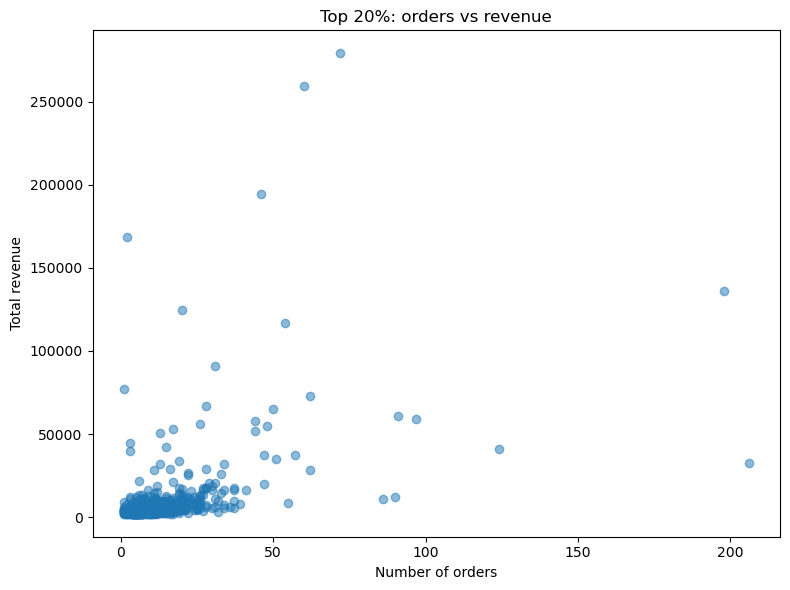

In [16]:
print("Recency:", top20["days_since_last_purchase"].describe())
print("\nFrequency:", top20["total_orders"].describe())
top20["ticket_avg"] = (top20["total_revenue"] / top20["total_orders"]).round(2)
med = top20["total_orders"].median()
recurrent = top20[top20["total_orders"] >= med]
high_ticket = top20[top20["total_orders"] < med]
print(f"\nRecurrent (many orders): {len(recurrent)}, avg order value {recurrent['ticket_avg'].mean():.2f}")
print(f"High ticket (fewer orders): {len(high_ticket)}, avg order value {high_ticket['ticket_avg'].mean():.2f}")
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(top20["total_orders"], top20["total_revenue"], alpha=0.5)
ax.set_xlabel("Number of orders")
ax.set_ylabel("Total revenue")
ax.set_title("Top 20%: orders vs revenue")
plt.tight_layout()
plt.show()

The UK dominates geographically — most customers and most revenue come from there. Customer concentration is high: roughly the top 20% account for ~75% of revenue, which is a pretty standard Pareto distribution but still worth keeping in mind operationally. Revenue is heavy-tailed, with a long tail of low-spending customers and a small number of very high-spenders. The top products by revenue include DOTCOM POSTAGE, REGENCY CAKESTAND, PAPER CRAFT, and various decorations.

## 8. Cohort analysis

Retention by first-purchase month. Rows = cohort, columns = months since first purchase.

months_since,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2010-12,100.0,36.5,32.4,38.3,36.2,39.8,36.2,34.8,35.3,39.5,37.3,50.2,26.5
2011-01,100.0,21.9,26.7,22.8,31.7,28.8,24.8,24.0,29.6,32.7,36.5,11.8,NaN
2011-02,100.0,18.7,18.7,28.7,27.1,24.5,25.5,27.4,24.7,30.5,6.8,NaN,NaN
2011-03,100.0,14.8,25.2,19.9,22.3,16.8,26.8,23.0,27.9,8.6,NaN,NaN,NaN
2011-04,100.0,21.0,20.3,21.0,19.7,22.7,21.7,26.0,7.3,NaN,NaN,NaN,NaN
2011-05,100.0,19.0,17.3,17.3,20.8,23.2,26.4,9.5,NaN,NaN,NaN,NaN,NaN
2011-06,100.0,17.4,15.7,26.4,23.1,33.1,9.5,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,17.6,20.3,22.5,27.3,11.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,20.1,24.3,24.3,12.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


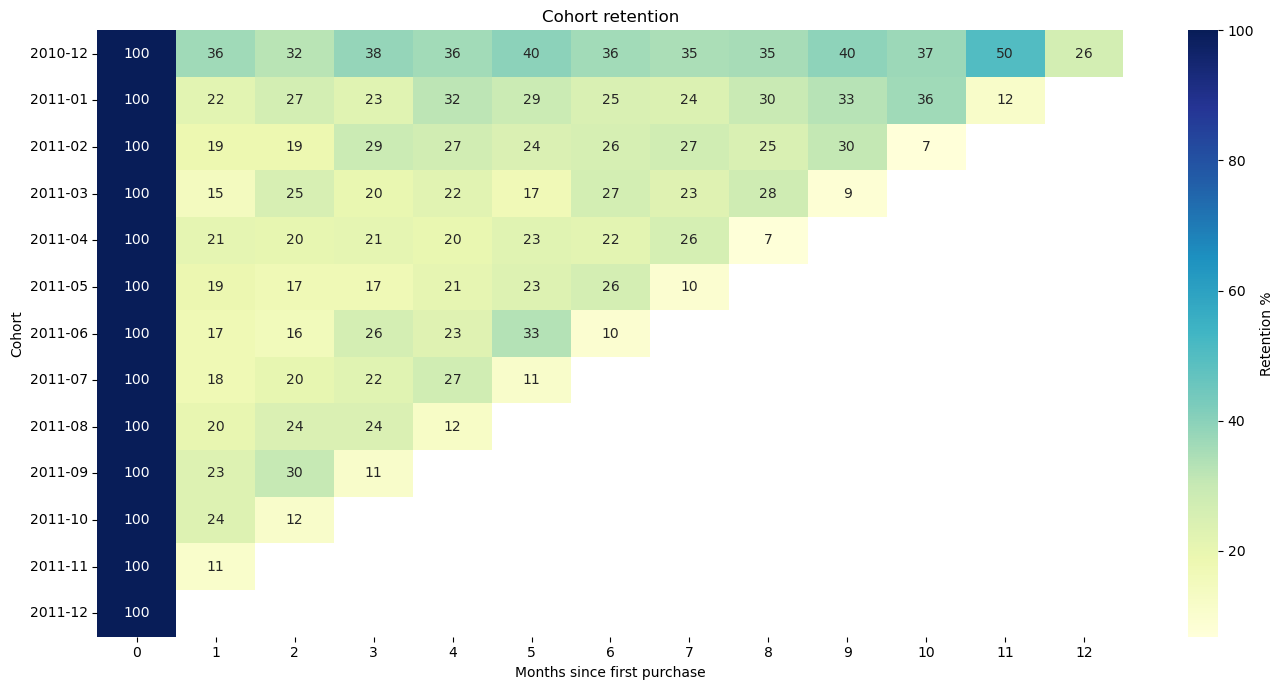

In [17]:
first_purchase = ecom2.groupby("CustomerID")["InvoiceDate"].min().reset_index()
first_purchase.columns = ["CustomerID", "first_date"]
first_purchase["cohort_month"] = first_purchase["first_date"].dt.to_period("M").dt.to_timestamp()
ecom2["order_month"] = ecom2["InvoiceDate"].dt.to_period("M").dt.to_timestamp()
orders_month = ecom2[["CustomerID", "order_month"]].drop_duplicates().merge(first_purchase[["CustomerID", "cohort_month"]], on="CustomerID")
orders_month["months_since"] = (orders_month["order_month"].dt.year - orders_month["cohort_month"].dt.year) * 12 + (orders_month["order_month"].dt.month - orders_month["cohort_month"].dt.month)
cohort_counts = orders_month.groupby(["cohort_month", "months_since"])["CustomerID"].nunique().reset_index()
cohort_counts.columns = ["cohort_month", "months_since", "n_customers"]
sz = cohort_counts[cohort_counts["months_since"] == 0][["cohort_month", "n_customers"]].rename(columns={"n_customers": "cohort_size"})
cohort_counts = cohort_counts.merge(sz, on="cohort_month")
cohort_counts["retention_pct"] = (cohort_counts["n_customers"] / cohort_counts["cohort_size"] * 100).round(1)
retention_matrix = cohort_counts.pivot(index="cohort_month", columns="months_since", values="retention_pct")
retention_matrix.index = retention_matrix.index.strftime("%Y-%m")
display(retention_matrix)
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(retention_matrix, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "Retention %"})
ax.set_title("Cohort retention")
ax.set_xlabel("Months since first purchase")
ax.set_ylabel("Cohort")
plt.tight_layout()
plt.show()

Typical e-commerce Month 1 retention is around 25–35%; Month 2 around 15–25%. The cohorts here show a fairly sharp drop-off in the first couple of months, which is in line with the norm for this type of business. Retention varies by cohort — older cohorts (e.g. Dec 2010) that had more time to come back naturally show higher long-term numbers. Overall: moderate retention, not exceptional but not alarming. The early drop-off window (months 1–2) is the main area to target.

## 9. Top products

Products ranked by total revenue, by quantity sold, and by average revenue per line.

In [18]:
g = ecom2.groupby("StockCode").agg(revenue=("Revenue", "sum"), qty=("Quantity", "sum"), desc=("Description", "first")).sort_values("revenue", ascending=False)
print("Top 10 by revenue:")
display(g.head(10))
print("Top 10 by quantity:")
display(g.sort_values("qty", ascending=False).head(10))
g["avg_rev"] = ecom2.groupby("StockCode")["Revenue"].mean()
print("Top 10 by avg revenue per line:")
display(g.sort_values("avg_rev", ascending=False).head(10)[["desc", "avg_rev"]].round(2))

Top 10 by revenue:


,revenue,qty,desc
StockCode,,,
22423,174484.74,13879,REGENCY CAKESTAND 3 TIER
23843,168469.60,80995,"PAPER CRAFT , LITTLE BIRDIE"
85123A,104518.80,37660,WHITE HANGING HEART T-LIGHT HOLDER
47566,99504.33,18295,PARTY BUNTING
85099B,94340.05,48474,JUMBO BAG RED RETROSPOT
23166,81700.92,78033,MEDIUM CERAMIC TOP STORAGE JAR
23084,66964.99,30788,RABBIT NIGHT LIGHT
22086,64952.29,19355,PAPER CHAIN KIT 50'S CHRISTMAS
84879,59094.93,36461,ASSORTED COLOUR BIRD ORNAMENT


Top 10 by quantity:


,revenue,qty,desc
StockCode,,,
23843,168469.60,80995,"PAPER CRAFT , LITTLE BIRDIE"
23166,81700.92,78033,MEDIUM CERAMIC TOP STORAGE JAR
22197,51354.02,56921,SMALL POPCORN HOLDER
84077,13841.85,55047,WORLD WAR 2 GLIDERS ASSTD DESIGNS
85099B,94340.05,48474,JUMBO BAG RED RETROSPOT
85123A,104518.80,37660,WHITE HANGING HEART T-LIGHT HOLDER
84879,59094.93,36461,ASSORTED COLOUR BIRD ORNAMENT
21212,21259.10,36419,PACK OF 72 RETROSPOT CAKE CASES
23084,66964.99,30788,RABBIT NIGHT LIGHT


Top 10 by avg revenue per line:


,desc,avg_rev
StockCode,,
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
47556B,TEA TIME TEA TOWELS,3022.50
22275,WEEKEND BAG VINTAGE ROSE PAISLEY,527.85
22833,HALL CABINET WITH 3 DRAWERS,520.71
22830,UTILTY CABINET WITH HOOKS,435.05
21897,POTTING SHED CANDLE CITRONELLA,422.73
23166,MEDIUM CERAMIC TOP STORAGE JAR,326.80
21769,VINTAGE POST OFFICE CABINET,303.83
22828,REGENCY MIRROR WITH SHUTTERS,218.57


## 10. UK-only view

Same metrics as above, filtered to United Kingdom only — useful since UK dominates the overall numbers and might be masking international patterns.

UK rows: 483969


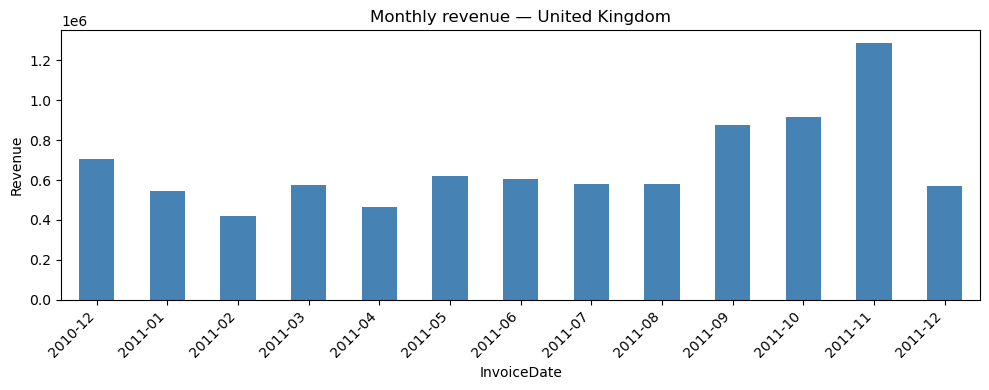

,total_revenue,total_orders,last_order_date,days_since,avg_order_value
CustomerID,,,,,
12346.0,77183.60,1,2011-01-18 10:01:00,325,77183.60
12747.0,4196.01,11,2011-12-07 14:34:00,1,381.46
12748.0,32317.26,206,2011-12-09 12:20:00,0,156.88
12749.0,4040.88,5,2011-12-06 09:56:00,3,808.18
12820.0,942.34,4,2011-12-06 15:12:00,2,235.58
12821.0,92.72,1,2011-05-09 15:51:00,213,92.72
12822.0,948.88,2,2011-09-30 10:04:00,70,474.44
12823.0,1759.50,5,2011-09-26 07:35:00,74,351.90
12824.0,397.12,1,2011-10-11 12:49:00,59,397.12


Top 10 products (UK) by revenue:


,revenue,desc
StockCode,,
23843,168469.60,"PAPER CRAFT , LITTLE BIRDIE"
22423,142273.29,REGENCY CAKESTAND 3 TIER
85123A,98723.75,WHITE HANGING HEART T-LIGHT HOLDER
47566,93658.53,PARTY BUNTING
85099B,86471.34,JUMBO BAG RED RETROSPOT
23166,80575.63,MEDIUM CERAMIC TOP STORAGE JAR
22086,62742.54,PAPER CHAIN KIT 50'S CHRISTMAS
84879,54756.79,ASSORTED COLOUR BIRD ORNAMENT
79321,53336.56,CHILLI LIGHTS


In [19]:
ecom_uk = ecom2[ecom2["Country"] == "United Kingdom"].copy()
print(f"UK rows: {len(ecom_uk)}")
month_uk = ecom_uk.set_index("InvoiceDate").resample("ME")["Revenue"].sum()
month_uk.index = month_uk.index.strftime("%Y-%m")
month_uk.plot(kind="bar", figsize=(10, 4), color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Revenue")
plt.title("Monthly revenue — United Kingdom")
plt.tight_layout()
plt.show()
rmf_uk = ecom_uk.groupby("CustomerID").agg(total_revenue=("Revenue", "sum"), total_orders=("InvoiceNo", "nunique"), last_order_date=("InvoiceDate", "max"))
rmf_uk["days_since"] = (ecom_uk["InvoiceDate"].max() - rmf_uk["last_order_date"]).dt.days
rmf_uk["avg_order_value"] = (rmf_uk["total_revenue"] / rmf_uk["total_orders"]).round(2)
display(rmf_uk.head(10))
print("Top 10 products (UK) by revenue:")
display(ecom_uk.groupby("StockCode").agg(revenue=("Revenue", "sum"), desc=("Description", "first")).sort_values("revenue", ascending=False).head(10))

## 11. Conclusions & recommendations

1. **Main revenue driver:** The UK and a small group of high-value customers. Geography and customer concentration explain most of the revenue pattern.

2. **Concentration is high.** The top 20% of customers generate ~75% of revenue. Geographic reliance on the UK is similarly concentrated.

3. **Seasonality is real.** Q4 (December) is the peak. There’s growth over the period, with dips in Feb/Apr.

4. **Retention is moderate.** Early drop-off is the main issue; cohorts that stick past month 2 tend to have decent long-term retention.

**If I were Head of Growth:**

1. **Protect the top 20%** — VIP program, early access, personalized offers. Losing even a handful of them would be disproportionately damaging.

2. **Improve early retention** — drip campaigns, post-purchase follow-up, and incentives in months 1–2 to reduce early drop-off.

3. **Diversify geography** — test marketing more seriously in Netherlands, Ireland, Germany, where there’s already some traction.

4. **Lean into seasonality** — stock and promo planning for Q4; start earlier with pre-holiday campaigns (Oct–Nov).

5. **Product focus** — push the high-margin, high-revenue items (REGENCY CAKESTAND, PAPER CRAFT, WHITE HANGING HEART T-LIGHT HOLDER); bundle top-quantity items (PAPER CRAFT, MEDIUM CERAMIC TOP STORAGE JAR) with higher-margin products to lift average order value.